In [47]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import os
import pathlib
import json

from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap

pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
np.random.seed(4)

In [31]:
#open data
data = pd.read_csv("/home/ganesh/soccermatics/data/FBRef 2020-21 T5 League Data - main.csv", na_values= '#DIV/0!')
#change minutes to numerics
data["Min"] = data["Min"].apply(lambda x: x.replace(",", "")).astype(int)

data = data.loc[data["Min"] > 500]
data = data.reset_index(drop = True)
data = data.convert_dtypes(convert_floating=True)
data = data.fillna(0)
X = data.iloc[:, 11:]
X.shape

(1959, 117)

In [36]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
#dim reduction
reducer = umap.UMAP(random_state = 2213)
comps = reducer.fit_transform(X)
comps.shape

(1959, 2)

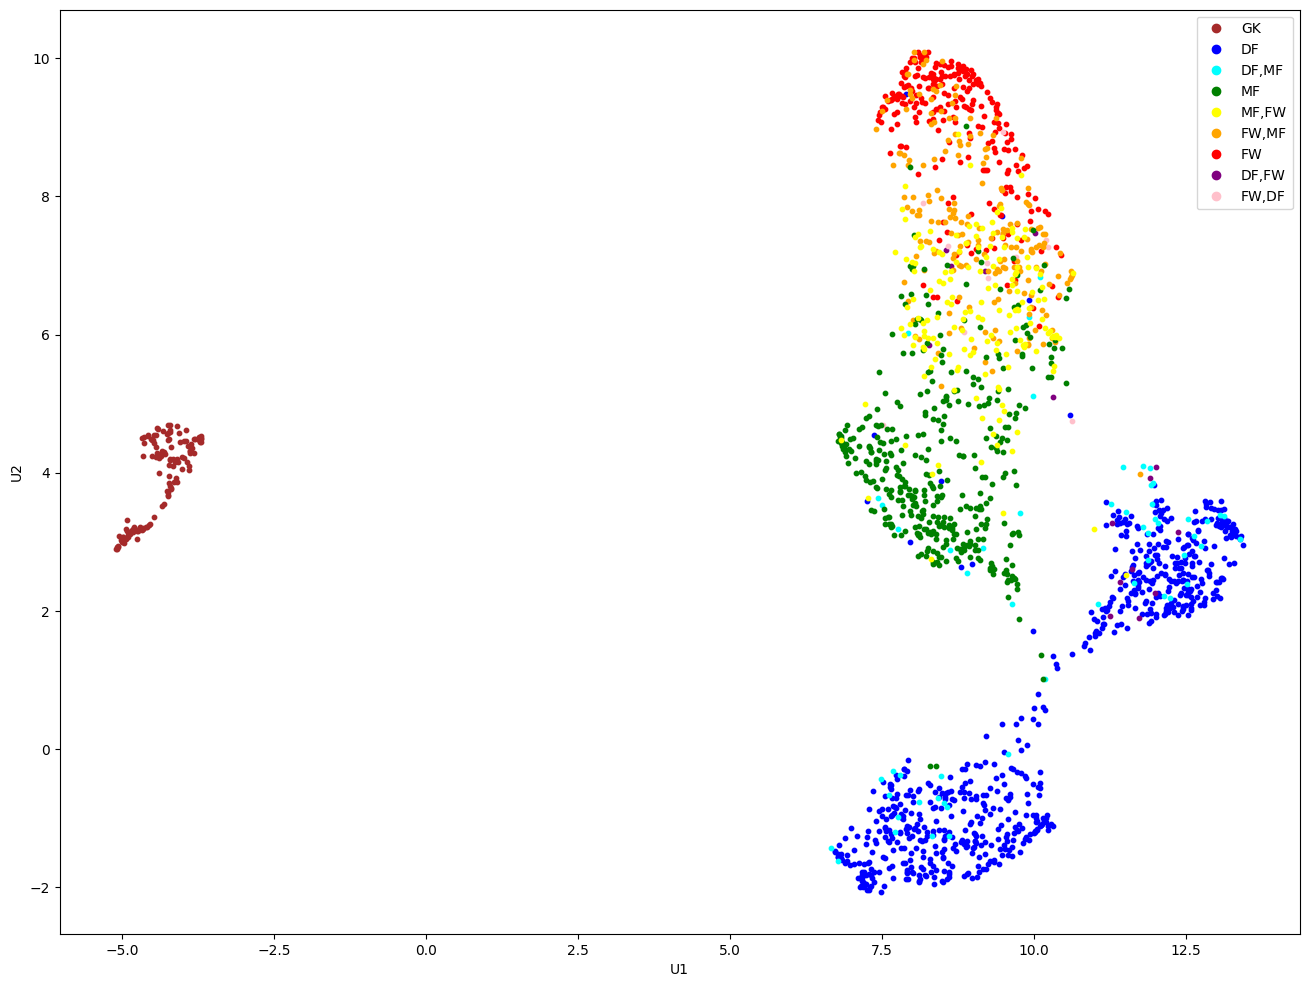

In [39]:
#plotting
fig, ax = plt.subplots(figsize = (16,12))
#map position to color
colors = {"GK": "brown", "DF": "blue", "DF,MF": "aqua", "MF": "green", "MF,FW": "yellow", "FW,MF": "orange", "FW": "red", 'DF,FW': "purple", 'FW,DF': "pink"}
color_list = data.Pos.map(colors).to_list()

#plot it
for i in range(X.shape[0]):
    ax.scatter(comps[i,0], comps[i,1], c = color_list[i], s = 10)
ax.set_xlabel('U1')
ax.set_ylabel('U2')
#make legend
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='') for color in colors.values()]
ax.legend(markers, colors.keys(), numpoints=1)
plt.show()

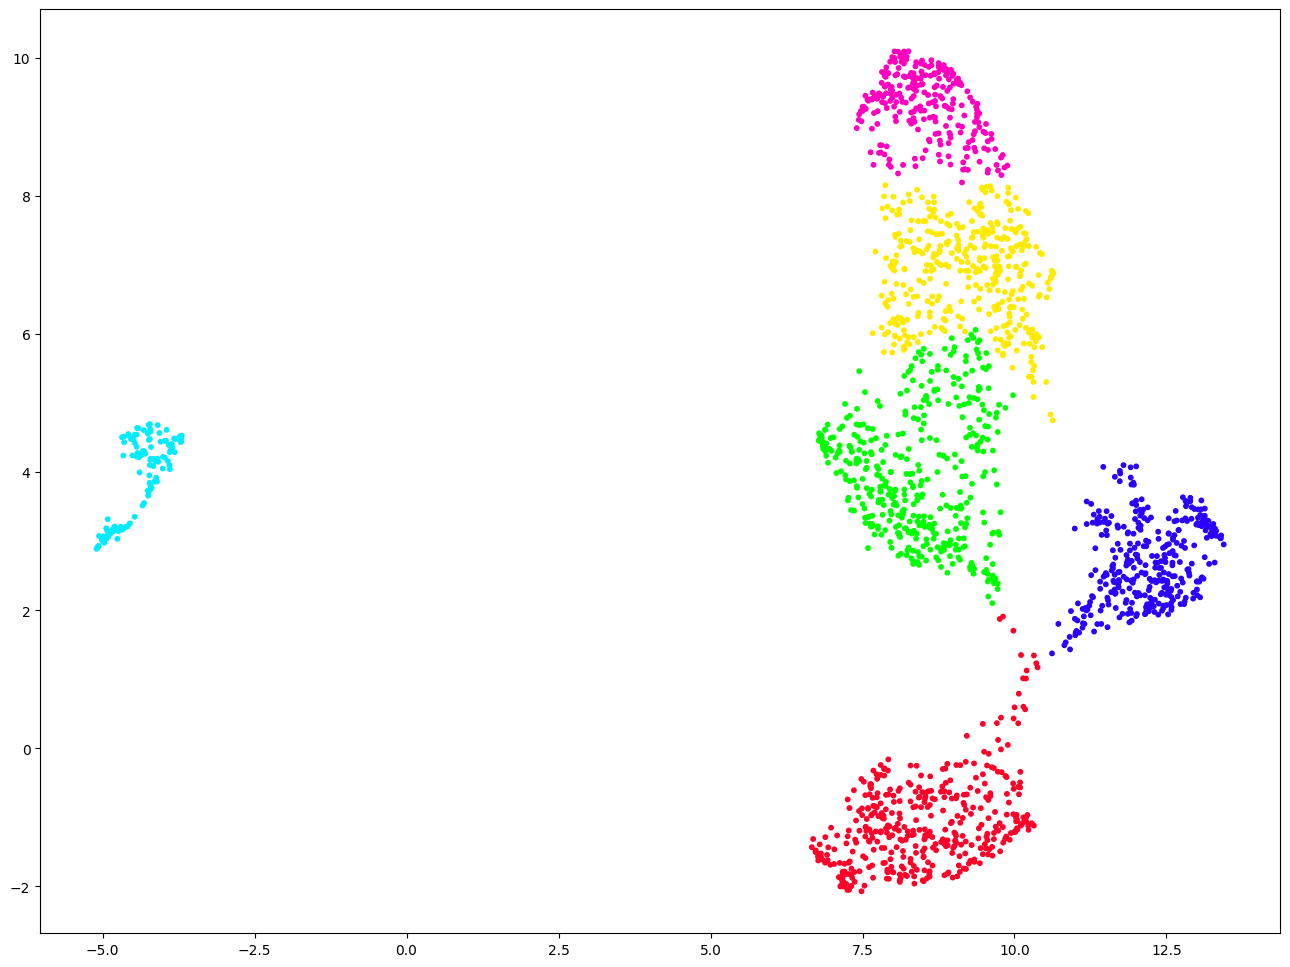

In [41]:
scan = AgglomerativeClustering(n_clusters=6)
#make predictions
labels = scan.fit_predict(comps)
fig, ax = plt.subplots(figsize = (16,12))
ax.scatter(comps[:, 0], comps[:, 1], c=labels, s=10, cmap='gist_rainbow');
plt.show()

                   Player  Nation    Pos       Squad           Comp  label
1215        Kevin Volland  de GER  FW,MF      Monaco     fr Ligue 1      5
1197  Stephan El Shaarawy  it ITA  FW,MF        Roma     it Serie A      1
719                 Chema  es ESP  DF,MF      Getafe     es La Liga      0
1437       Marc Cucurella  es ESP     MF      Getafe     es La Liga      1
404          Pablo Maffeo  es ESP     DF      Huesca     es La Liga      4
1710  Aurélien Tchouaméni  fr FRA     MF      Monaco     fr Ligue 1      2
1878          Rade Krunić  ba BIH  MF,FW       Milan     it Serie A      1
994          Manu Vallejo  es ESP     FW    Valencia     es La Liga      5
767       Ludovic Ajorque  re REU     FW  Strasbourg     fr Ligue 1      5
356          Lukas Kübler  de GER     DF    Freiburg  de Bundesliga      4


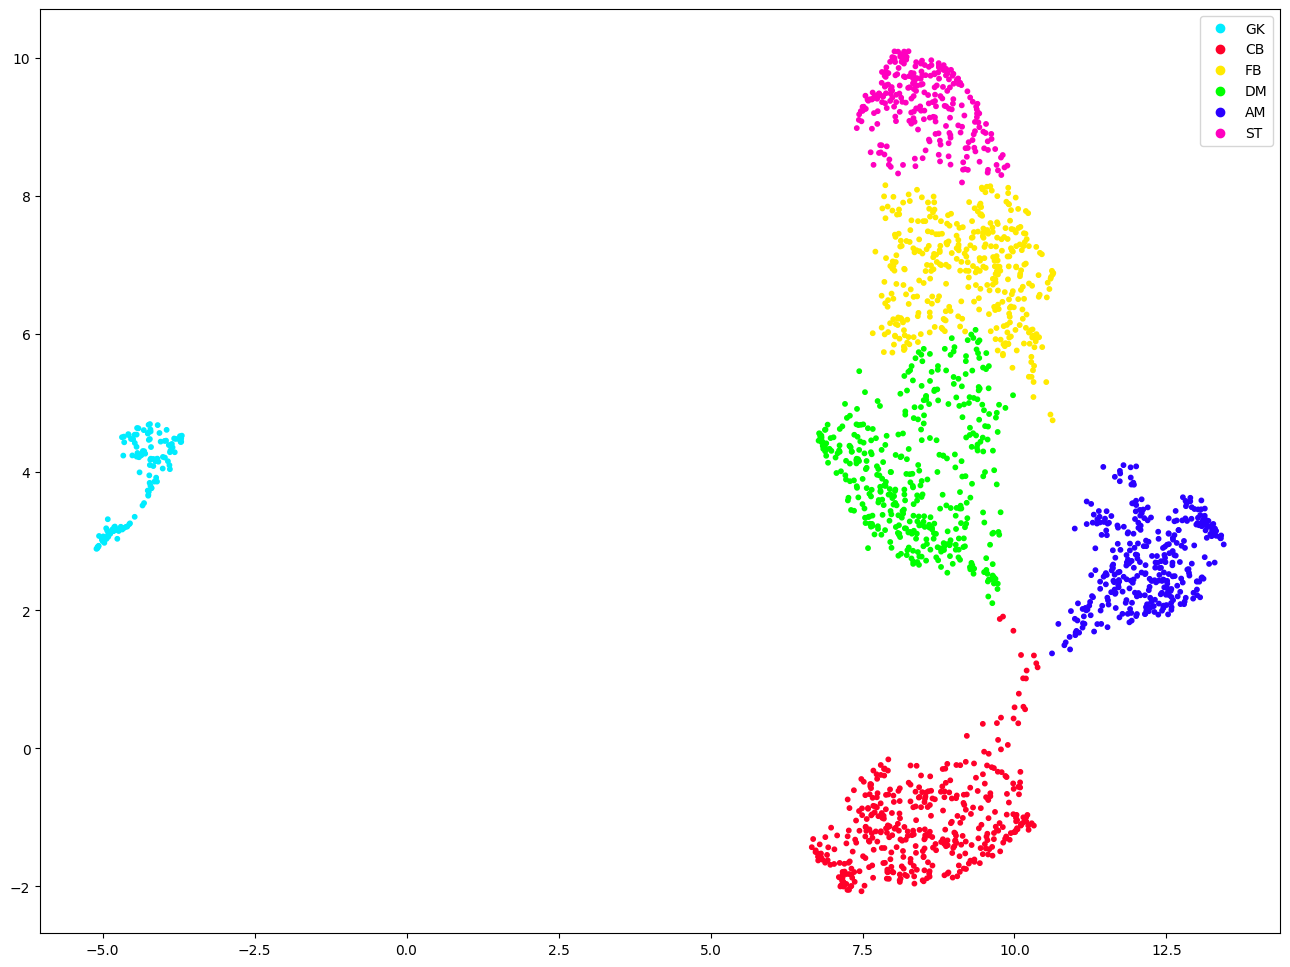

In [42]:
#explore the dataframe
see = data.iloc[:, 0:5]
see["label"] = labels
print(see.sample(frac = 1).head(10))

#plot predictions with a legend
fig, ax = plt.subplots(figsize = (16,12))
scatter = ax.scatter(comps[:, 0], comps[:, 1], c=labels, s=10, cmap='gist_rainbow');
handles = scatter.legend_elements()[0]
#order the labels for hierarchy
myorder = [3,0,1,2,4,5]
handles = [handles[i] for i in myorder]
#add legend
ax.legend(handles=handles, labels = ["GK", "CB", "FB", "DM", "AM", "ST"])
plt.show()


In [44]:
pca = PCA()
tsne = TSNE(random_state = 3454)
#declare pipeline
ts = Pipeline([    ('pca', pca),
    ('tsne', tsne)
])
#reduce dimensions
comps = ts.fit_transform(X)
comps.shape

(1959, 2)

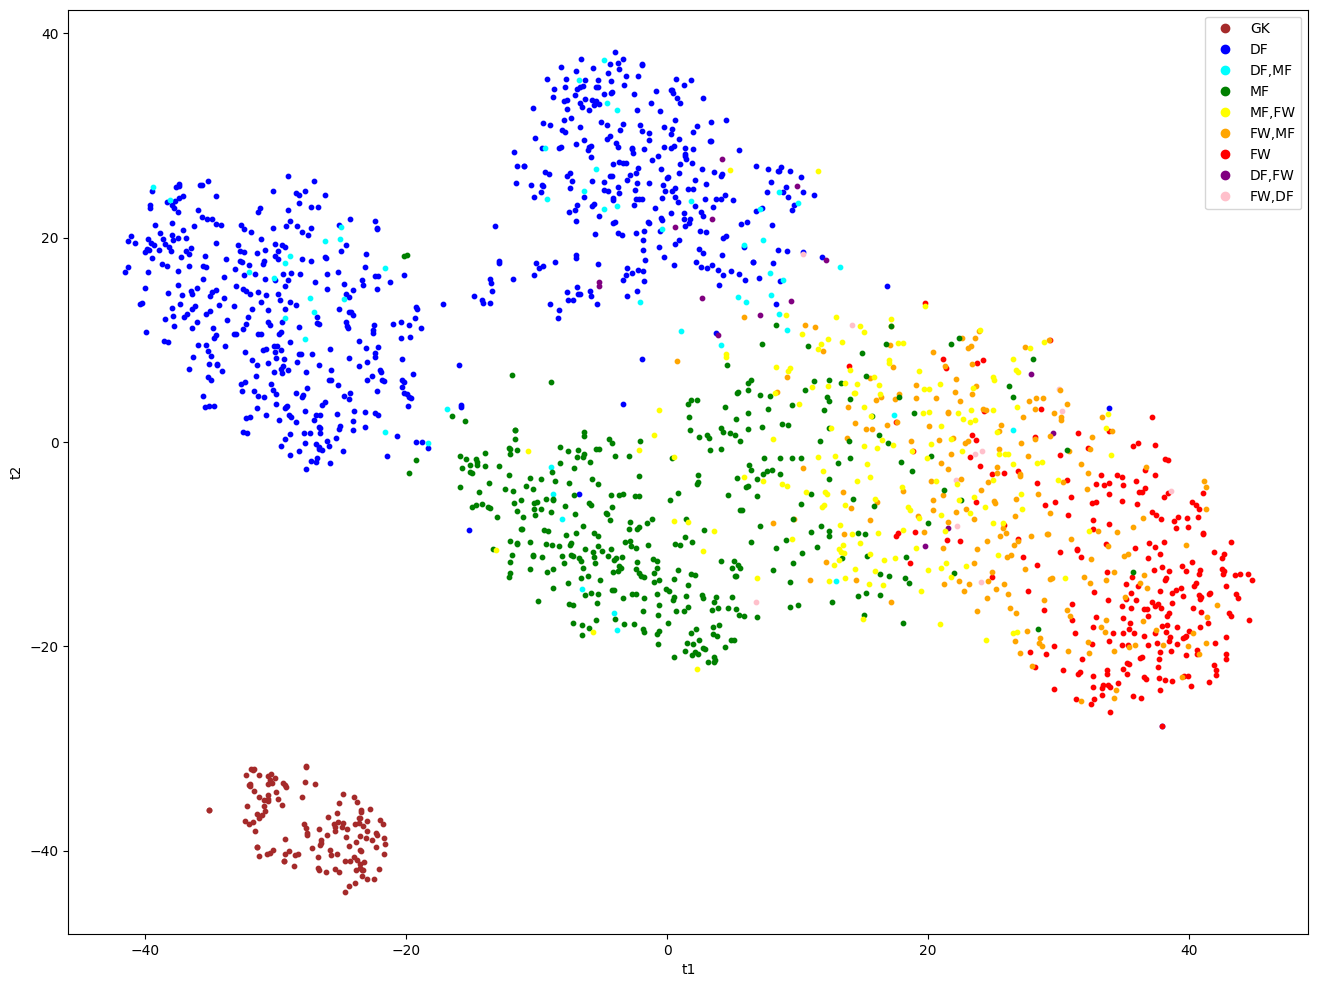

In [45]:
fig, ax = plt.subplots(figsize = (16,12))
for i in range(X.shape[0]):
    ax.scatter(comps[i,0], comps[i,1], c = color_list[i], s = 10)
ax.set_xlabel('t1')
ax.set_ylabel('t2')
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='') for color in colors.values()]
ax.legend(markers, colors.keys(), numpoints=1)
plt.show()

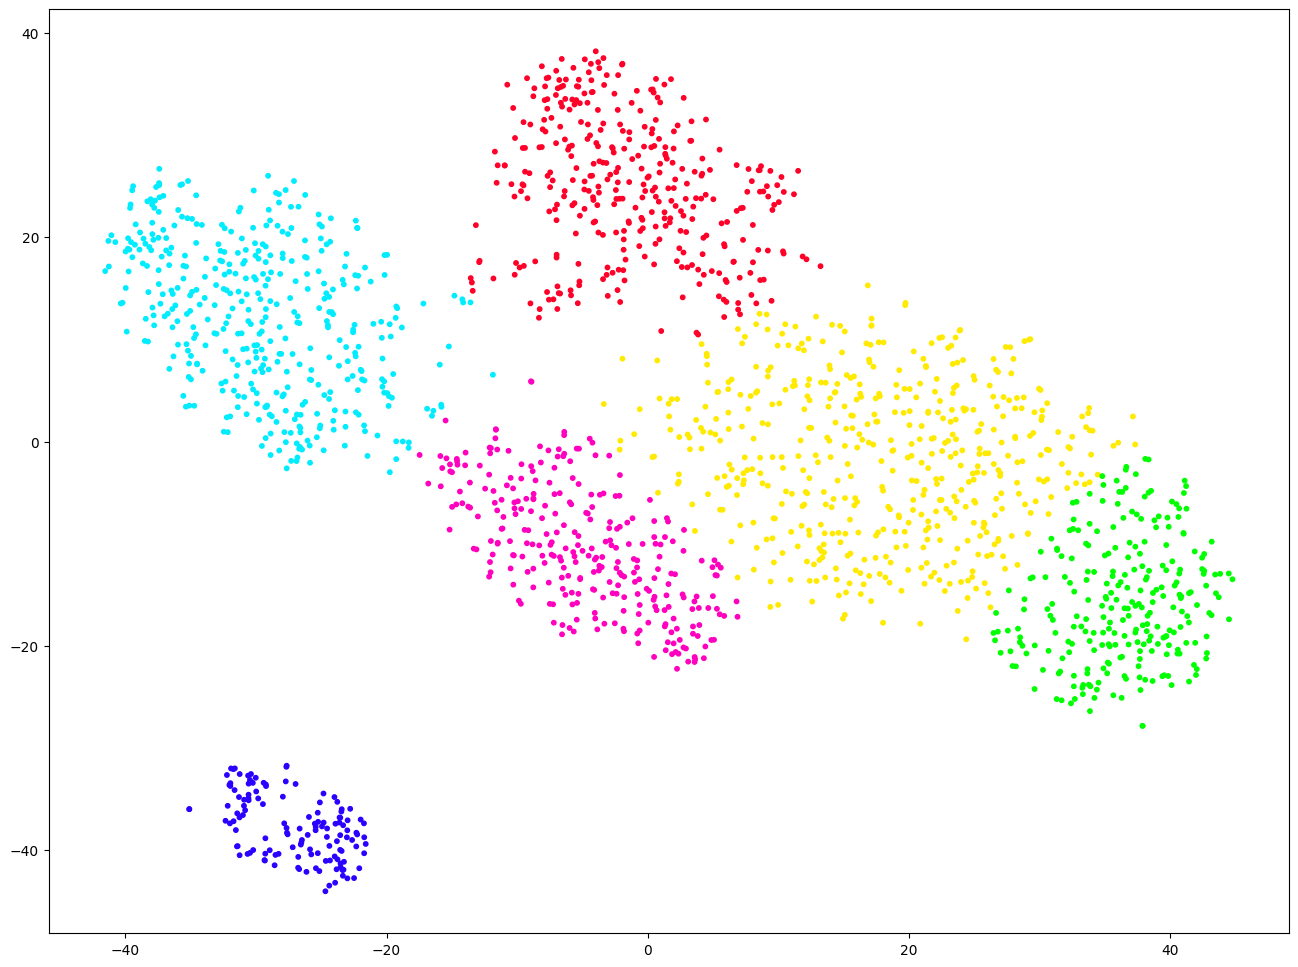

In [48]:
gmm = GaussianMixture(n_components=6, random_state=5).fit(comps)
#make predictions
labels = gmm.predict(comps)
fig, ax = plt.subplots(figsize = (16,12))
plt.scatter(comps[:, 0], comps[:, 1], c=labels, s=10, cmap='gist_rainbow');
plt.show()

                  Player   Nation    Pos        Squad                Comp  \
674   Kyle Walker-Peters  eng ENG     DF  Southampton  eng Premier League   
1522        Jens Jønsson   dk DEN     MF        Cádiz          es La Liga   
1770    Riccardo Improta   it ITA  MF,DF    Benevento          it Serie A   
253      Darnell Furlong  eng ENG     DF    West Brom  eng Premier League   
1627   Exequiel Palacios   ar ARG     MF   Leverkusen       de Bundesliga   
1618          Mark Noble  eng ENG     MF     West Ham  eng Premier League   
378      Clément Lenglet   fr FRA     DF    Barcelona          es La Liga   
1241     Andrea Consigli   it ITA     GK     Sassuolo          it Serie A   
1394        Fran Beltrán   es ESP     MF   Celta Vigo          es La Liga   
1447      Kerem Demirbay   de GER     MF   Leverkusen       de Bundesliga   

      label  
674       0  
1522      5  
1770      0  
253       0  
1627      5  
1618      5  
378       3  
1241      4  
1394      5  
1447      1 

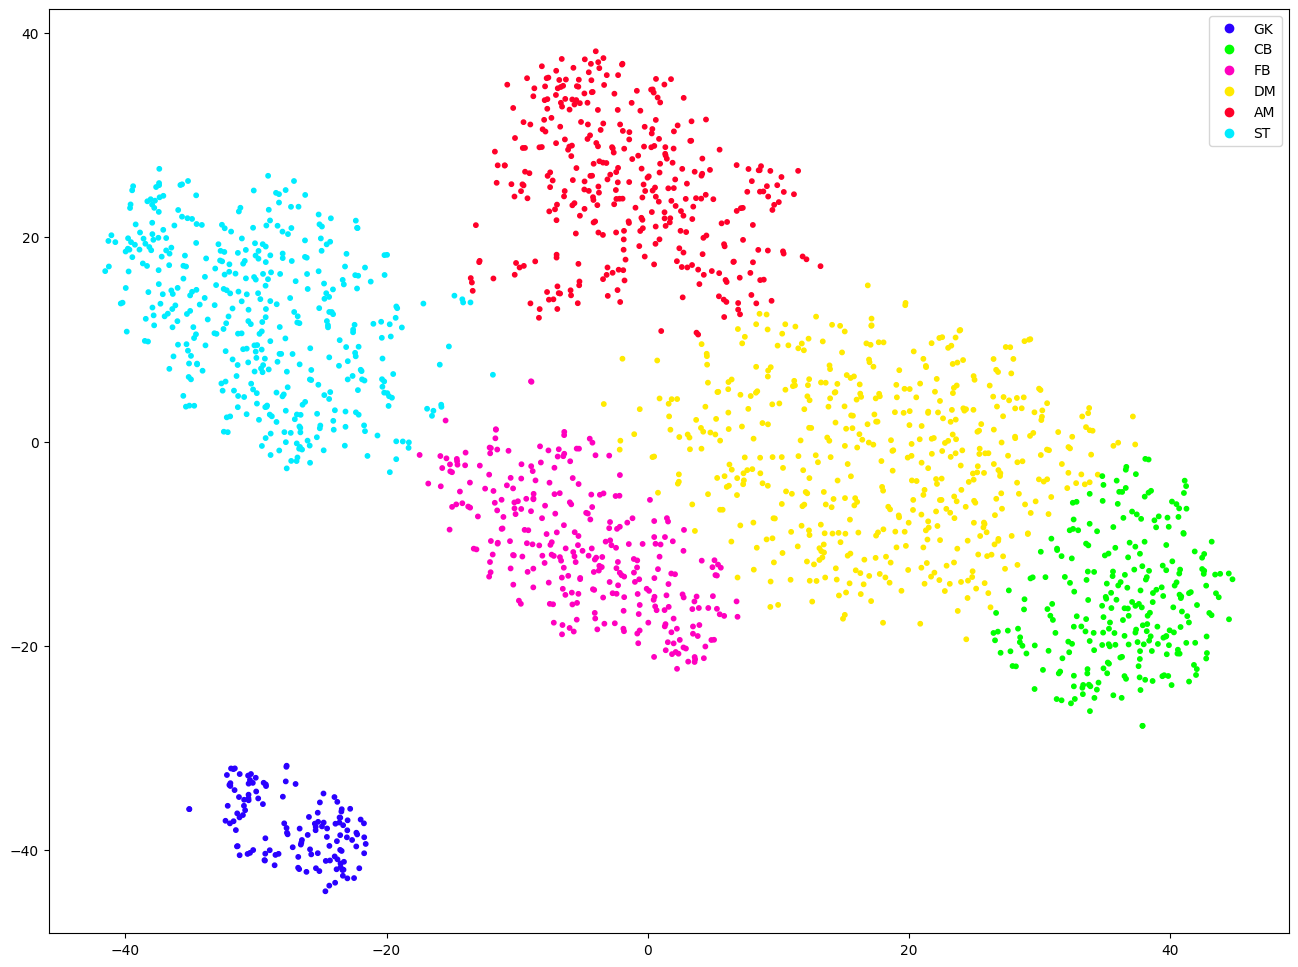

In [51]:
see = data.iloc[:, 0:5]
see["label"] = labels
print(see.sample(frac = 1).head(10))

#explore the dataframe
fig, ax = plt.subplots(figsize = (16,12))
scatter = ax.scatter(comps[:, 0], comps[:, 1], c=labels, s=10, cmap='gist_rainbow');
handles = scatter.legend_elements()[0]
#order the labels for hierarchy
myorder = [4,2,5,1,0,3]
handles = [handles[i] for i in myorder]
ax.legend(handles=handles, labels = ["GK", "CB", "FB", "DM", "AM", "ST"])
plt.show()